In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
SHP_PATH = '/content/drive/MyDrive/2026/project_augur/electorial_regions (1).geojson'

APP_DIR = globals().get('APP_DIR','/content/drive/MyDrive/2026/project_augur/app')

REPO_OWNER='carnman'
REPO_NAME='augur'

REPO_URL=f'https://github.com/{REPO_OWNER}/{REPO_NAME}.git'

YOUR_GITHUB_EMAIL = globals().get('YOUR_GITHUB_EMAIL','hau.ma.benjamin@gmail.com')

os.makedirs(APP_DIR, exist_ok=True)
print('APP_DIR =', APP_DIR)
print('SHP_PATH =', SHP_PATH)
print('REPO_URL =', REPO_URL)

APP_DIR = /content/drive/MyDrive/2026/project_augur/app
SHP_PATH = /content/drive/MyDrive/2026/project_augur/electorial_regions (1).geojson
REPO_URL = https://github.com/carnman/augur.git


In [ ]:
import pandas as pd

In [ ]:
oevk_names = pd.read_csv('/content/drive/MyDrive/2026/project_augur/post election evaluation/oevk_lookup.csv')

party_shares = pd.read_csv('/content/drive/MyDrive/2026/project_augur/post election evaluation/party share extracts/partyshares_test1.csv')
party_shares = party_shares.merge(oevk_names, left_on='const_id', right_on='OEVK', how='left')

In [ ]:
def prepare_party_shares(input_path, output_path):
    cols_to_keep = [
        'const_id', 'constituency_name',
        'share_fidesz', 'share_tisza', 'share_dk', 'share_otherleft', 'share_otherright',
        'count_fidesz', 'count_tisza', 'count_dk', 'count_otherleft', 'count_otherright', 'count_dnv',
        'winner'
    ]

    df = pd.read_csv(input_path)
    df = df.merge(oevk_names, left_on='const_id', right_on='OEVK', how='left')
    df = df[cols_to_keep]
    df.to_excel(output_path, index=False)
    print(f"Saved {len(df)} rows to {output_path}")
    return df


# Run for each scenario
BASE = '/content/drive/MyDrive/2026/project_augur/post election evaluation'

scenarios = {
    'central':       'partyshares_Apr12 final Data, 74% TO, Base Case.csv',
    'likely_voters': 'partyshares_Apr12 final Data, 80% TO, VLikely Voters.csv',
     'high_turnout':  'partyshares 	Apr12 final Data, 80% TO.csv',
    'v2 early april': 'partyshares_v2 23 plan, 5%p margin target replication attempt.csv',
   # 'no_dnv':        'partyshares_test4.csv',
}

for scenario, filename in scenarios.items():
    prepare_party_shares(
        input_path=f'{BASE}/party share extracts/{filename}',
        output_path=f'{BASE}/party share extracts/{scenario}_clean.xlsx'
    )

true_results = pd.read_excel(f'{BASE}/true_results.xlsx')
print(f"Loaded true results: {len(true_results)} rows")

Saved 106 rows to /content/drive/MyDrive/2026/project_augur/post election evaluation/party share extracts/central_clean.xlsx
Saved 106 rows to /content/drive/MyDrive/2026/project_augur/post election evaluation/party share extracts/likely_voters_clean.xlsx
Saved 106 rows to /content/drive/MyDrive/2026/project_augur/post election evaluation/party share extracts/high_turnout_clean.xlsx
Saved 106 rows to /content/drive/MyDrive/2026/project_augur/post election evaluation/party share extracts/v2 early april_clean.xlsx
Loaded true results: 106 rows


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

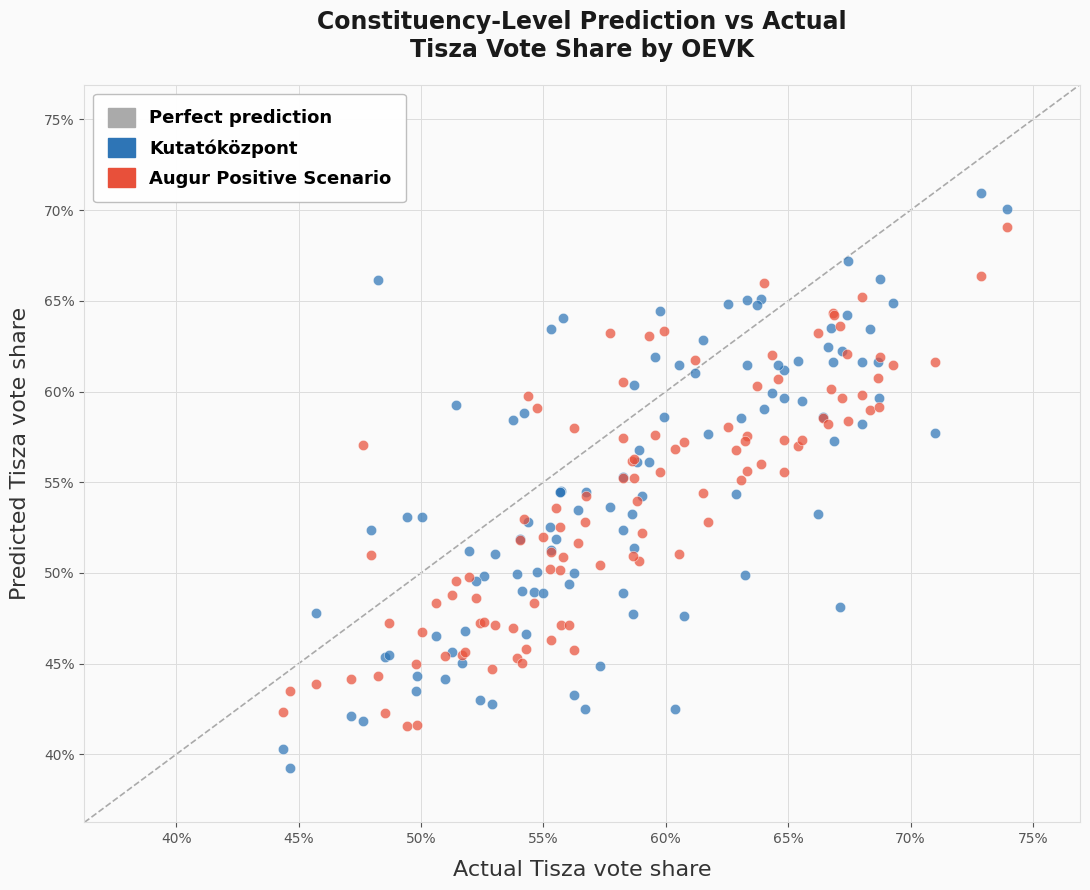

In [ ]:
def plot_tisza_scatter(true_results, scenario_dfs: dict, figsize=(11, 9)):
    COLORS = ['#2E75B6', '#E8503A', '#4CAF50', '#9B59B6']

    fig, ax = plt.subplots(figsize=figsize, facecolor='#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    all_pred = np.concatenate([df['share_tisza'].values for df in scenario_dfs.values()])
    all_true = true_results['share_tisza'].values
    lo = min(all_pred.min(), all_true.min()) - 0.03
    hi = max(all_pred.max(), all_true.max()) + 0.03

    ax.plot([lo, hi], [lo, hi], color='#AAAAAA', lw=1.2, ls='--', zorder=1)
    legend_handles = [mpatches.Patch(color='#AAAAAA', label='Perfect prediction')]

    for i, (label, df) in enumerate(scenario_dfs.items()):
        color = COLORS[i % len(COLORS)]
        merged = df.merge(
            true_results[['const_id', 'share_tisza']].rename(columns={'share_tisza': 'share_tisza_true'}),
            on='const_id'
        )
        x = merged['share_tisza_true'].values
        y = merged['share_tisza'].values

        ax.scatter(x, y, color=color, alpha=0.72, s=55, zorder=3, linewidths=0.4, edgecolors='white')
        legend_handles.append(mpatches.Patch(color=color, label=label))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_xlabel('Actual Tisza vote share', fontsize=16, labelpad=10, color='#333333')
    ax.set_ylabel('Predicted Tisza vote share', fontsize=16, labelpad=10, color='#333333')
    ax.set_title('Constituency-Level Prediction vs Actual\nTisza Vote Share by OEVK',
                 fontsize=17, fontweight='bold', color='#1a1a1a', pad=20)
    ax.tick_params(colors='#555555', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
    ax.grid(True, color='#DDDDDD', linewidth=0.7, zorder=0)
    ax.legend(handles=legend_handles, frameon=True, framealpha=0.95,
              fontsize=13, loc='upper left', edgecolor='#BBBBBB',
              prop={'size': 13, 'weight': 'bold'},
              handlelength=1.5, handleheight=1.2,
              borderpad=0.8, labelspacing=0.6)

    plt.tight_layout()
    plt.show()

scenario_dfs = {
    #'Augur Base Case Prediction': pd.read_excel(f'{BASE}/party share extracts/central_clean.xlsx'),
    'Kutatóközpont': pd.read_excel(f'{BASE}/party share extracts/kutato_clean_28march.xlsx'),
   'Augur Positive Scenario': pd.read_excel(f'{BASE}/party share extracts/likely_voters_clean.xlsx'),
  # 'High Turnout':  pd.read_excel(f'{BASE}/party share extracts/high_turnout_clean.xlsx'),
  # 'No DNV':        pd.read_excel(f'{BASE}/party share extracts/no_dnv_clean.xlsx'),
}

plot_tisza_scatter(true_results, scenario_dfs)

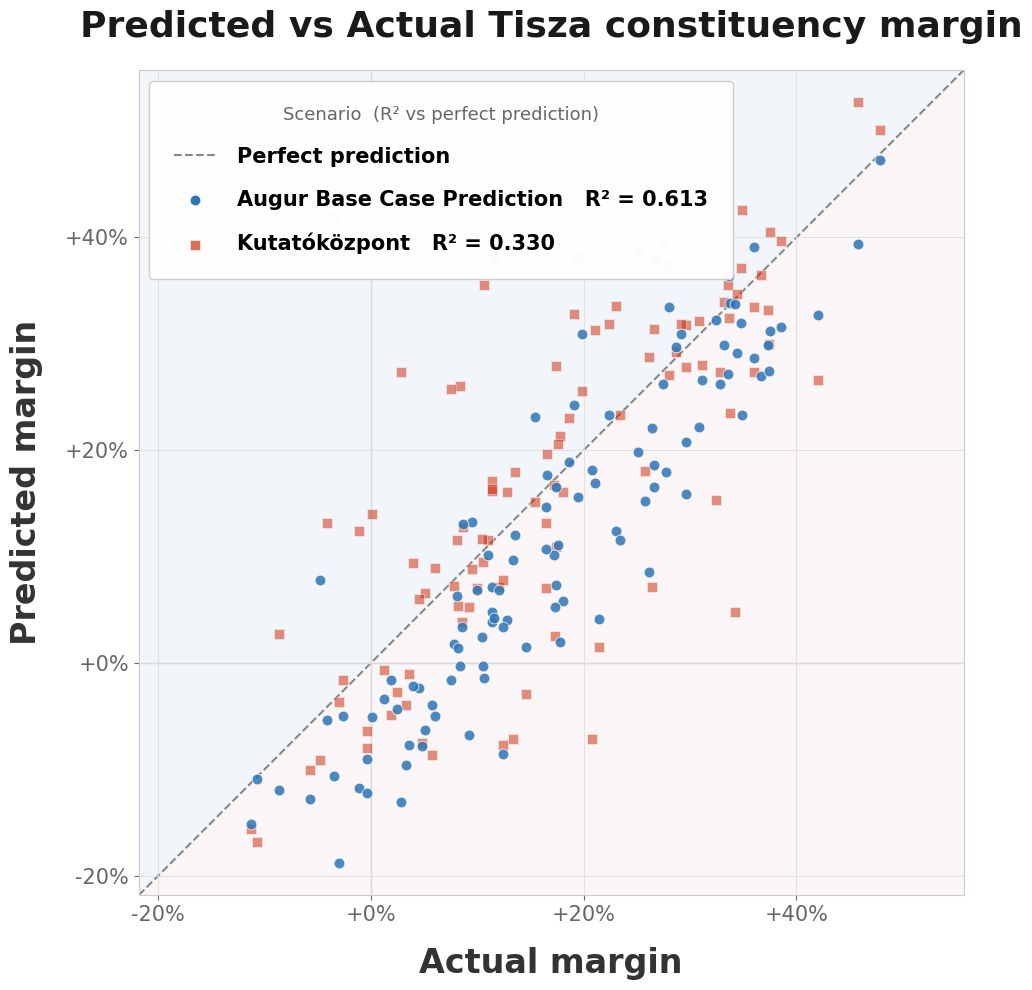

In [ ]:
def plot_tisza_margin_scatter(true_results, scenario_dfs: dict, figsize=(13, 10)):

    SCENARIO_STYLES = {
        'Augur Base Case':  {'color': '#2E75B6', 'alpha': 0.85, 'size': 60, 'zorder': 4, 'marker': 'o'},
        'Augur Optimistic': {'color': '#1A4A7A', 'alpha': 0.85, 'size': 60, 'zorder': 4, 'marker': 'o'},
        'Kutatóközpont':    {'color': '#CC2200', 'alpha': 0.50, 'size': 45, 'zorder': 2, 'marker': 's'},
    }
    DEFAULT_OUR   = {'color': '#2E75B6', 'alpha': 0.85, 'size': 60, 'zorder': 4, 'marker': 'o'}
    DEFAULT_OTHER = {'color': '#CC2200', 'alpha': 0.50, 'size': 45, 'zorder': 2, 'marker': 's'}

    def get_margin(df):
        if 'share_tisza_norm' not in df.columns:
            df = df.copy()
            denom = df['share_tisza'] + df['share_fidesz']
            df['share_tisza_norm'] = df['share_tisza'] / denom
        df = df.copy()
        df['margin_norm'] = 2 * df['share_tisza_norm'] - 1
        return df

    true = true_results.copy()
    true['margin_true'] = 2 * true['share_tisza'] - 1

    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    ax.set_facecolor('#F7F9FC')

    all_pred, all_true = [], []
    for df in scenario_dfs.values():
        df = get_margin(df)
        merged = df.merge(true[['const_id', 'margin_true']], on='const_id')
        all_pred.extend(merged['margin_norm'].tolist())
        all_true.extend(merged['margin_true'].tolist())

    lo = min(min(all_pred), min(all_true)) - 0.03
    hi = max(max(all_pred), max(all_true)) + 0.03

    ax.plot([lo, hi], [lo, hi], color='#888888', lw=1.5, ls='--', zorder=1)
    ax.axhline(0, color='#CCCCCC', lw=1.0, zorder=1)
    ax.axvline(0, color='#CCCCCC', lw=1.0, zorder=1)
    ax.fill_between([lo, hi], [lo, hi], hi, color='#EEF4FB', alpha=0.5, zorder=0)
    ax.fill_between([lo, hi], lo, [lo, hi], color='#FEF3F1', alpha=0.5, zorder=0)

    legend_handles = [
        plt.Line2D([0], [0], color='#888888', lw=1.5, ls='--', label='Perfect prediction')
    ]

    for label, df in scenario_dfs.items():
        df = get_margin(df)
        merged = df.merge(true[['const_id', 'margin_true']], on='const_id')
        x = merged['margin_true'].values
        y = merged['margin_norm'].values

        ss_res = np.sum((y - x) ** 2)
        ss_tot = np.sum((x - x.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        style = SCENARIO_STYLES.get(label, DEFAULT_OUR if 'Augur' in label else DEFAULT_OTHER)

        ax.scatter(x, y, color=style['color'], alpha=style['alpha'],
                   s=style['size'], zorder=style['zorder'],
                   marker=style['marker'], linewidths=0.6, edgecolors='white')

        legend_handles.append(
            plt.scatter([], [], color=style['color'],
                        alpha=min(style['alpha'] + 0.15, 1.0),
                        s=style['size'], marker=style['marker'],
                        edgecolors='white', linewidths=0.6,
                        label=f'{label}   R² = {r2:.3f}')
        )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

    import matplotlib.ticker as mticker
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.20))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.20))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0%}'))

    ax.set_xlabel('Actual margin', fontsize=24, labelpad=16,
                  color='#333333', fontweight='bold')
    ax.set_ylabel('Predicted margin', fontsize=24, labelpad=16,
                  color='#333333', fontweight='bold')
    ax.set_title('Predicted vs Actual Tisza constituency margin',
                 fontsize=26, fontweight='bold', color='#1a1a1a', pad=24)
    ax.tick_params(colors='#666666', labelsize=15)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
    ax.grid(True, color='#DDDDDD', linewidth=0.6, zorder=0)

    legend = ax.legend(handles=legend_handles,
                       frameon=True, framealpha=0.97,
                       edgecolor='#CCCCCC',
                       loc='upper left',
                       prop={'size': 15, 'weight': 'bold'},
                       handletextpad=1.0,
                       borderpad=1.2,
                       labelspacing=1.1,
                       title='Scenario  (R² vs perfect prediction)',
                       title_fontsize=13)
    legend.get_title().set_color('#666666')

    plt.tight_layout()
    plt.show()


scenario_dfs = {
    #'Augur Base Case': pd.read_excel(f'{BASE}/party share extracts/v2 early april_clean.xlsx'),
    'Augur Base Case Prediction': pd.read_excel(f'{BASE}/party share extracts/central_clean.xlsx'),
    #'Augur Positive Scenario': pd.read_excel(f'{BASE}/party share extracts/likely_voters_clean.xlsx'),

    'Kutatóközpont':   pd.read_excel(f'{BASE}/party share extracts/kutato_clean_28march.xlsx'),
}

plot_tisza_margin_scatter(true_results, scenario_dfs)

In [ ]:
import os
for f in os.listdir(f'{BASE}/party share extracts/'):
    print(f)

partyshares_test1.gsheet
partyshares_test1.csv
partyshares 	Apr12 final Data, 80% TO.csv
kutato_clean_28march.xlsx
partyshares_Apr12 final Data, 80% TO, VLikely Voters.csv
partyshares_Apr12 final Data, 74% TO, Base Case.csv
central_clean_dev.xlsx
partyshares_v2 23 plan, 5%p margin target replication attempt.csv
central_clean.xlsx
high_turnout_clean.xlsx
likely_voters_clean.xlsx
v2 early april_clean.xlsx


# National Share Inspection

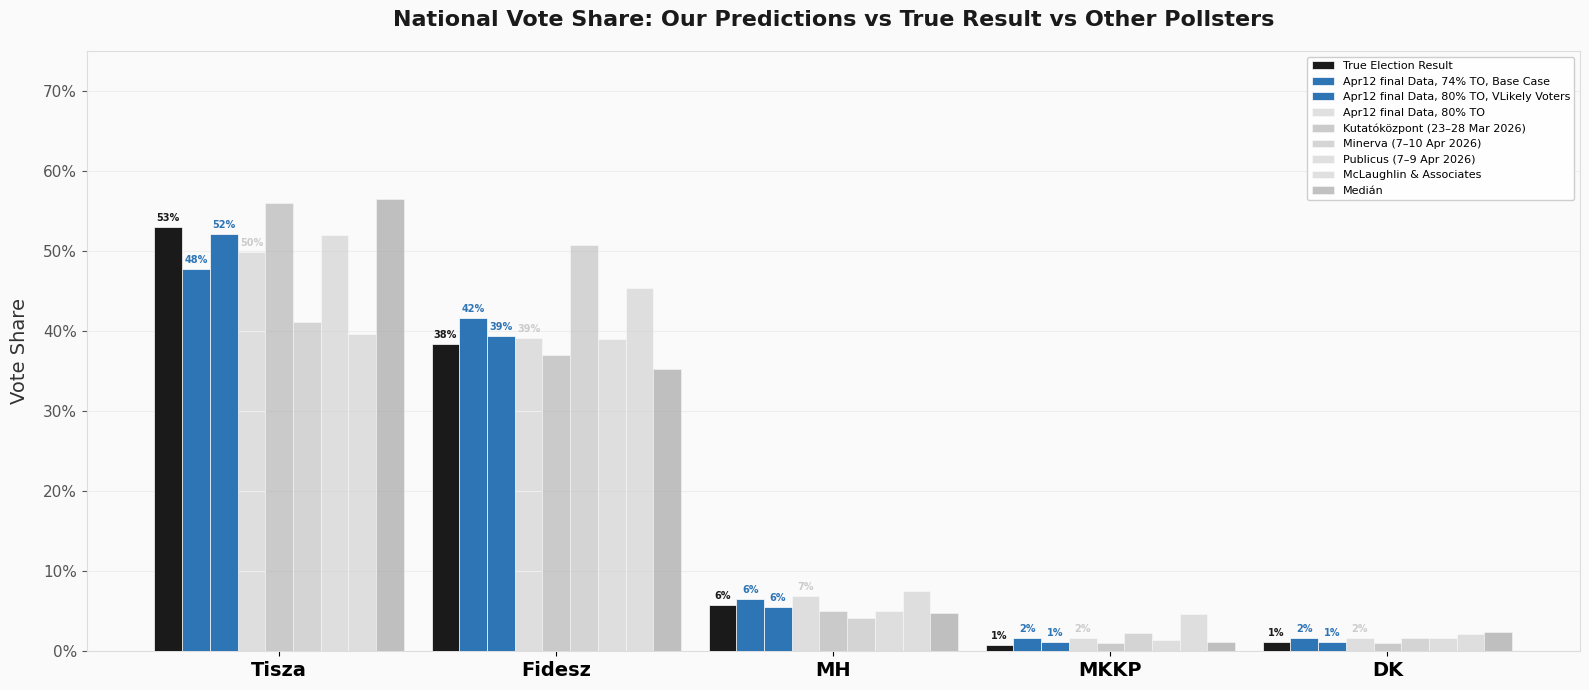

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('/content/drive/MyDrive/2026/project_augur/post election evaluation/Headline Predictions (1).xlsx')
df['Version'] = df['Version'].str.strip().str.replace(r'^\d+\s*', '', regex=True)
df = df.dropna(subset=['Pct'])  # drop rows with no data yet

VERSION_STYLES = {
    'True Election Result':                              {'color': '#1a1a1a', 'alpha': 1.0, 'zorder': 5},
    'Apr12 final Data, 74% TO, Base Case':               {'color': '#2E75B6', 'alpha': 1.0, 'zorder': 4},
   # 'Apr12 final Data, 80% TO':                          {'color': '#5BA3D9', 'alpha': 1.0, 'zorder': 4},
    'Apr12 final Data, 80% TO, VLikely Voters':          {'color': '#2E75B6', 'alpha': 1.0, 'zorder': 4},
    #'Apr12 final Data, 74% TO, Negative Scenario no 2022 DNV': {'color': '#7FB3D9', 'alpha': 1.0, 'zorder': 4},
    'Kutatóközpont (23–28 Mar 2026)':                    {'color': '#AAAAAA', 'alpha': 0.6, 'zorder': 2},
    'Minerva (7–10 Apr 2026)':                           {'color': '#BBBBBB', 'alpha': 0.6, 'zorder': 2},
    'Publicus (7–9 Apr 2026)':                           {'color': '#CCCCCC', 'alpha': 0.6, 'zorder': 2},
    'McLaughlin & Associates':                           {'color': '#CCCCCC', 'alpha': 0.6, 'zorder': 2},
    'Medián':                                            {'color': '#999999', 'alpha': 0.6, 'zorder': 2},
}

OUR_VERSIONS = {
    'Apr12 final Data, 74% TO, Base Case',
    'Apr12 final Data, 80% TO',
    'Apr12 final Data, 80% TO, VLikely Voters',
    'Apr12 final Data, 74% TO, Negative Scenario no 2022 DNV',
}

parties    = ['Tisza', 'Fidesz', 'MH', 'MKKP', 'DK']
versions   = df['Version'].unique()
n_versions = len(versions)
x          = np.arange(len(parties))
bar_w      = 0.10

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

for i, version in enumerate(versions):
    sub    = df[df['Version'] == version].set_index('Party')
    style  = VERSION_STYLES.get(version, {'color': '#CCCCCC', 'alpha': 0.6, 'zorder': 1})
    is_key = version in OUR_VERSIONS or version == 'True Election Result'

    vals = [sub.loc[p, 'Pct'] if p in sub.index else 0 for p in parties]
    bars = ax.bar(x + i * bar_w, vals, bar_w,
                  color=style['color'], alpha=style['alpha'],
                  zorder=style['zorder'],
                  edgecolor='white', linewidth=0.5,
                  label=version)

    if is_key:
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{v:.0%}', ha='center', va='bottom',
                        fontsize=7, fontweight='bold', color=style['color'])

ax.set_xticks(x + bar_w * (n_versions - 1) / 2)
ax.set_xticklabels(parties, fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(axis='y', labelsize=11, colors='#555555')
ax.set_ylabel('Vote Share', fontsize=14, color='#333333', labelpad=10)
ax.set_title('National Vote Share: Our Predictions vs True Result vs Other Pollsters',
             fontsize=16, fontweight='bold', color='#1a1a1a', pad=18)
ax.set_ylim(0, 0.75)
for spine in ax.spines.values():
    spine.set_edgecolor('#DDDDDD')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8, zorder=0)
ax.legend(fontsize=8, frameon=True, framealpha=0.95,
          edgecolor='#CCCCCC', loc='upper right',
          prop={'size': 8})

plt.tight_layout()
plt.show()

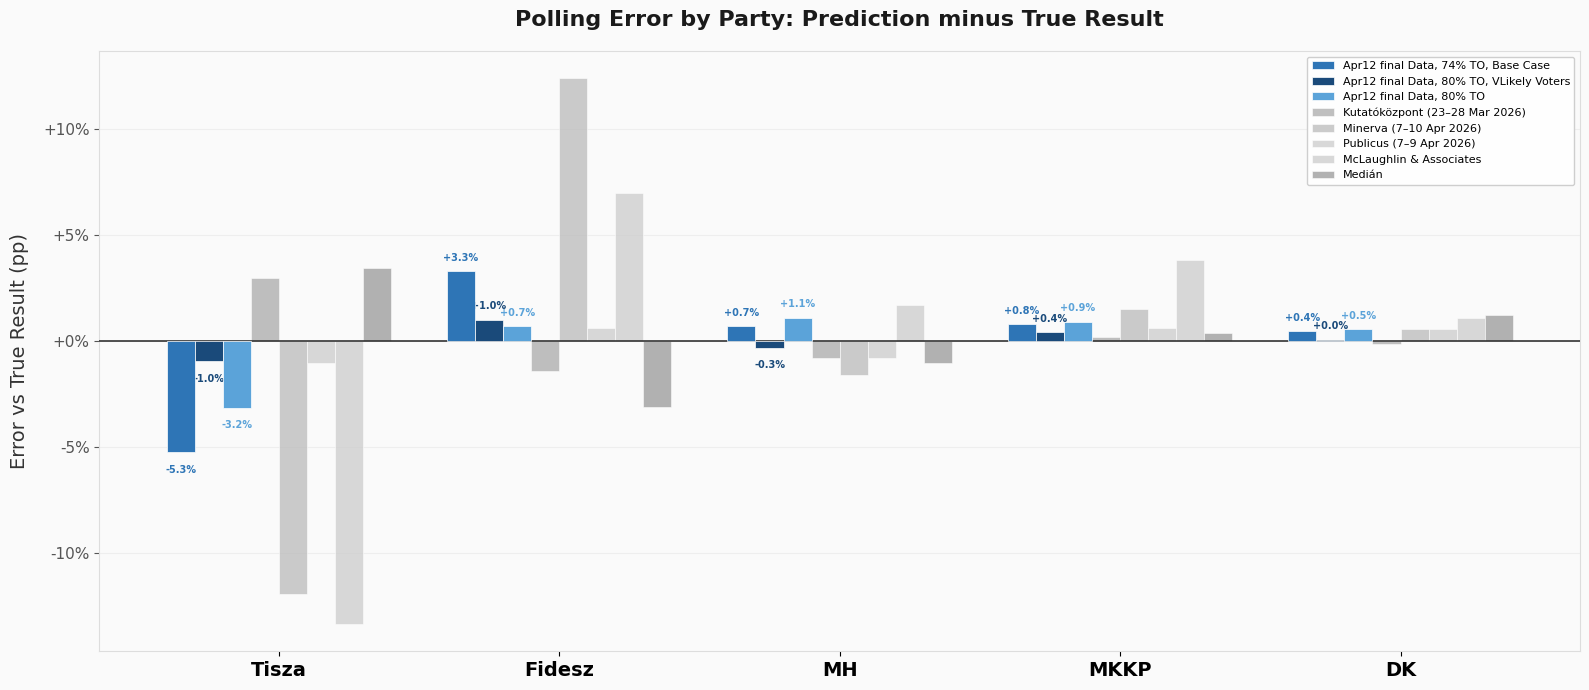

In [ ]:
true = df[df['Version'] == 'True Election Result'].set_index('Party')['Pct']
predictors = [v for v in df['Version'].unique() if v != 'True Election Result']

ERROR_STYLES = {
    'Apr12 final Data, 74% TO, Base Case':               {'color': '#2E75B6', 'alpha': 1.0, 'zorder': 4},
    'Apr12 final Data, 80% TO':                          {'color': '#5BA3D9', 'alpha': 1.0, 'zorder': 4},
    'Apr12 final Data, 80% TO, VLikely Voters':          {'color': '#1A4A7A', 'alpha': 1.0, 'zorder': 4},
    'Apr12 final Data, 74% TO, Negative Scenario no 2022 DNV': {'color': '#7FB3D9', 'alpha': 1.0, 'zorder': 4},
    'Kutatóközpont (23–28 Mar 2026)':                    {'color': '#AAAAAA', 'alpha': 0.75, 'zorder': 2},
    'Minerva (7–10 Apr 2026)':                           {'color': '#BBBBBB', 'alpha': 0.75, 'zorder': 2},
    'Publicus (7–9 Apr 2026)':                           {'color': '#CCCCCC', 'alpha': 0.75, 'zorder': 2},
    'McLaughlin & Associates':                           {'color': '#CCCCCC', 'alpha': 0.75, 'zorder': 2},
    'Medián':                                            {'color': '#999999', 'alpha': 0.75, 'zorder': 2},
}

OUR_VERSIONS = {
    'Apr12 final Data, 74% TO, Base Case',
    'Apr12 final Data, 80% TO',
    'Apr12 final Data, 80% TO, VLikely Voters',
    'Apr12 final Data, 74% TO, Negative Scenario no 2022 DNV',
}

parties    = ['Tisza', 'Fidesz', 'MH', 'MKKP', 'DK']
n_pred     = len(predictors)
x          = np.arange(len(parties))
bar_w      = 0.10

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.axhline(0, color='#333333', linewidth=1.2, zorder=3)

for i, version in enumerate(predictors):
    sub    = df[df['Version'] == version].set_index('Party')['Pct']
    style  = ERROR_STYLES.get(version, {'color': '#CCCCCC', 'alpha': 0.6, 'zorder': 1})
    is_key = version in OUR_VERSIONS

    errors = [sub.get(p, np.nan) - true.get(p, np.nan) for p in parties]
    bars   = ax.bar(x + i * bar_w, errors, bar_w,
                    color=style['color'], alpha=style['alpha'],
                    zorder=style['zorder'],
                    edgecolor='white', linewidth=0.5,
                    label=version)

    if is_key:
        for bar, e in zip(bars, errors):
            if not np.isnan(e):
                ax.text(bar.get_x() + bar.get_width()/2,
                        e + (0.004 if e >= 0 else -0.006),
                        f'{e:+.1%}', ha='center',
                        va='bottom' if e >= 0 else 'top',
                        fontsize=7, fontweight='bold', color=style['color'])

ax.set_xticks(x + bar_w * (n_pred - 1) / 2)
ax.set_xticklabels(parties, fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.tick_params(axis='y', labelsize=11, colors='#555555')
ax.set_ylabel('Error vs True Result (pp)', fontsize=14, color='#333333', labelpad=10)
ax.set_title('Polling Error by Party: Prediction minus True Result',
             fontsize=16, fontweight='bold', color='#1a1a1a', pad=18)
for spine in ax.spines.values():
    spine.set_edgecolor('#DDDDDD')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8, zorder=0)
ax.legend(fontsize=8, frameon=True, framealpha=0.95,
          edgecolor='#CCCCCC', loc='upper right',
          prop={'size': 8})

plt.tight_layout()
plt.show()